# Origin of the LEGA-C spectrum vs COSMOS photometry tilt

- Fits from `scripts/calibration_polynomial_experiment.py`, one RTX 5070 per target (same boot per target).
- `ap3` = production photometry (COSMOS2015 3" apertures + total IRAC); `cosmos_total` = Laigle et al. (2016) recipe; `uvista_total` = Muzzin et al. (2013) SED that calibrated the DR2 spectra.
- `poly3` arms profile the order-3 Chebyshev calibration inside the spectrum likelihood.
- Follow-up arms (`total_noirac*`, second boot per target) drop the IRAC bands, then also u, from the corrected photometry.

In [1]:
import os, sys, json
os.environ.setdefault("JAX_PLATFORMS", "cpu")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib, matplotlib.ticker
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.table import Table
from scipy.special import softmax
import corner
PROJECT = Path(r"/Users/liuhao/Downloads/Astro project/tmp/worktrees/astro-calibration-polynomial")
sys.path.insert(0, str(PROJECT.parent / "ceridwen-calibration-polynomial")); sys.path.insert(0, str(PROJECT / "scripts"))
from ceridwen.fit import load_result_h5
from ceridwen.model import logsfr_ratios_to_sfh
from ceridwen.cosmology import age_gyr
from sedpy_jax import observate
from specutils.utils.wcs_utils import air_to_vac
import calibration_polynomial_experiment as X
RESULTS = Path(os.environ.get("TILT_RESULTS", PROJECT / "results/tilt-origin-2026-09-02"))
WIKI = PROJECT / "wiki/analyses"; WIKI.mkdir(parents=True, exist_ok=True)
runs = {p.parent.name: json.loads(p.read_text()) for p in sorted(RESULTS.glob("*/summary.json"))}
vectors = {name: np.load(RESULTS / name / "vectors.npz") for name in runs}
TARGETS = ["M5_172669", "M4_108989"]
BANDS = ["u", "B", "V", "r", "i", "z", "Y", "J", "H", "Ks", "ch1", "ch2"]
PARAMS = ["logmass", "Z", "afe", "tau_dust", "mass_weighted_age_gyr"]
LABELS = {"logmass": r"$\log M_\star$", "Z": r"$\log Z$", "afe": r"[$\alpha$/Fe]", "tau_dust": r"$\tau_{\rm dust}$",
          "mass_weighted_age_gyr": r"$t_{\rm MW}$ [Gyr]", "spectrum_scaling": "spectrum_scaling", "f_calib_percent": r"$f_{\rm calib}$ [%]",
          "diffuse_dust_index": r"$\delta_{\rm dust}$"}
def amplitude_key(p): return next(k for k in p if k.startswith("diffuse_tau"))
def half_width(q): return 0.5 * (q["q84"] - q["q16"])
print(len(runs), "arms:", list(runs))

46 arms: ['M4_108989_ap3_calzetti', 'M4_108989_ap3_floor02_baseline', 'M4_108989_ap3_floor02_poly3', 'M4_108989_ap3_floor05_baseline', 'M4_108989_ap3_floor05_poly3', 'M4_108989_ap3_floor15_baseline', 'M4_108989_ap3_floor15_poly3', 'M4_108989_ap3_freeindex', 'M4_108989_cosmos_total_baseline', 'M4_108989_cosmos_total_poly1_dustprior', 'M4_108989_cosmos_total_poly3', 'M4_108989_photonly_ap3', 'M4_108989_photonly_cosmos_total', 'M4_108989_speconly', 'M4_108989_total_allbands_baseline', 'M4_108989_total_allbands_poly3', 'M4_108989_total_noirac_baseline', 'M4_108989_total_noirac_nou_baseline', 'M4_108989_total_noirac_nou_poly3', 'M4_108989_total_noirac_poly3', 'M4_108989_total_noirac_speconly', 'M4_108989_uvista_total_baseline', 'M4_108989_uvista_total_poly3', 'M5_172669_ap3_calzetti', 'M5_172669_ap3_floor02_baseline', 'M5_172669_ap3_floor02_poly3', 'M5_172669_ap3_floor05_baseline', 'M5_172669_ap3_floor05_poly3', 'M5_172669_ap3_floor15_baseline', 'M5_172669_ap3_floor15_poly3', 'M5_172669_ap3

## Model-independent check inside the spectral range

- Synthetic IA679, IB709, IA738, IA767, IB827 fluxes from each DR2 spectrum against four photometric SEDs.
- `total` applies Offset, `E(B-V)` and the Table 3 offsets; `uvista` scales Muzzin fluxes by `FKstot/FKs`.

,target,sed,IA679,IB709,IA738,IA767,IB827,tilt_pct
0,M5_172669,"COSMOS2015 3"" (production)",1.105,1.309,1.348,1.450,1.262,14.260
1,M5_172669,"COSMOS2015 2""",1.383,1.620,1.701,1.851,1.633,18.060
2,M5_172669,"COSMOS2015 total, offsets applied",1.044,1.021,1.051,1.130,1.015,-2.841
3,M5_172669,UltraVISTA total (DR2 calibrator),1.032,0.964,1.020,1.094,0.960,-6.966
4,M4_108989,"COSMOS2015 3"" (production)",1.212,1.480,1.420,1.460,1.472,21.405
5,M4_108989,"COSMOS2015 2""",1.775,2.184,2.023,2.058,2.168,22.132
6,M4_108989,"COSMOS2015 total, offsets applied",0.801,0.808,0.774,0.795,0.826,3.105
7,M4_108989,UltraVISTA total (DR2 calibrator),0.993,1.036,0.922,0.941,0.967,-2.637


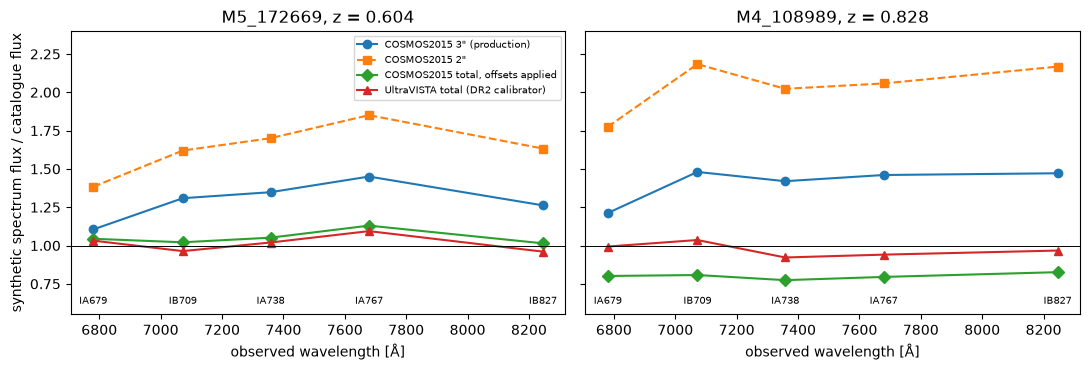

In [2]:
IB = ["IA679", "IB709", "IA738", "IA767", "IB827"]
IB_FILTERS = observate.load_filters([f"subaru_suprimecam_{b.lower().replace('ib', 'ia')}" for b in IB])
IB_SF = {"IA679": -0.194, "IB709": 0.017, "IA738": 0.020, "IA767": 0.024, "IB827": -0.005}
IB_EXT = {"IA679": 2.430, "IB709": 2.289, "IA738": 2.150, "IA767": 1.996, "IB827": 1.747}
apertures = Table.read(PROJECT / "data/raw/cosmos2015/cosmos2015_legac_dr2_apertures_1arcsec.fits")
uvista = Table.read(PROJECT / "data/raw/ultravista/ultravista_legac_dr2_1arcsec.fits")
selected = X.select_passive(PROJECT)
def synth(wave, maggies, f):
    fw = np.asarray(f.wavelength); ft = np.asarray(f.transmission)
    inside = (fw >= wave.min()) & (fw <= wave.max())
    sp = np.interp(fw[inside], wave, maggies)
    return float(np.trapezoid(sp * ft[inside] / fw[inside], fw[inside]) / np.trapezoid(ft[inside] / fw[inside], fw[inside]))
ib_rows = []
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, target in zip(axes, TARGETS):
    g = selected[selected["SPECT_ID"] == target].iloc[0]
    wave_air, flux, err, good, _ = X.load_spectrum(PROJECT, g["Filename"])
    wave = air_to_vac(wave_air * u.AA).to_value(u.AA)
    maggies = X.flam_to_fnu_cgs(flux, wave) / 3631e-23
    ok = good & np.isfinite(maggies) & (maggies > 0)
    syn = np.array([synth(wave[ok], maggies[ok], f) for f in IB_FILTERS])
    leff = np.array([float(f.wave_effective) for f in IB_FILTERS])
    c15 = apertures[np.asarray(apertures["LEGAC_INDEX"]) == int(g.name)][0]
    uv = uvista[np.asarray(uvista["LEGAC_INDEX"]) == int(g.name)][0]
    ap3 = np.array([c15[f"F{b}ap3"] for b in IB]) * X.UJY_TO_MAGGIES
    ap2 = np.array([c15[f"F{b}ap2"] for b in IB]) * X.UJY_TO_MAGGIES
    corr = np.array([float(c15["Offset"]) - float(c15["E(B-V)"]) * IB_EXT[b] - IB_SF[b] for b in IB])
    total = ap3 * 10 ** (-0.4 * corr)
    uvt = np.array([uv[f"F{b}"] for b in IB]) * float(uv["FKstot"]) / float(uv["FKs"]) * X.UJY_TO_MAGGIES
    for label, arr, style in (("COSMOS2015 3\" (production)", ap3, "o-"), ("COSMOS2015 2\"", ap2, "s--"),
                              ("COSMOS2015 total, offsets applied", total, "D-"), ("UltraVISTA total (DR2 calibrator)", uvt, "^-")):
        r = syn / arr
        ax.plot(leff, r, style, label=label)
        ib_rows.append(dict(target=target, sed=label, **{b: float(v) for b, v in zip(IB, r)}, tilt_pct=100 * (r[-1] / r[0] - 1)))
    ax.axhline(1, color="k", lw=0.7); ax.set_title(f"{target}, z = {g['z']:.3f}"); ax.set_xlabel(r"observed wavelength [$\mathrm{\AA}$]")
    for b, x in zip(IB, leff): ax.text(x, 0.62, b, ha="center", fontsize=7)
axes[0].set_ylabel("synthetic spectrum flux / catalogue flux"); axes[0].set_ylim(0.55, 2.4); axes[0].legend(fontsize=7)
fig.tight_layout(); fig.savefig(RESULTS / "ibands.png", dpi=140); fig.savefig(WIKI / "calibration-polynomial-tilt-origin-ibands.png", dpi=140)
ib_table = pd.DataFrame(ib_rows); ib_table.to_csv(RESULTS / "ibands.csv", index=False); ib_table.round(3)

## Arms table

- One row per arm: configuration, evidence, posterior medians and 16–84 half widths, photometric χ² of the median model, polynomial tilt `P(8800)/P(6600) − 1`.

In [3]:
rows = []
for name, s in runs.items():
    c, p, m = s["config"], s["posterior"], s["meta"]
    amp = amplitude_key(p)
    row = dict(arm=name, target=c["target"], photometry=c["photometry"], floor=c["phot_floor"], fit=c["fit"], order=c["poly_order"],
               dust_law=c["dust_law"], free_index=c["free_dust_index"], dust_prior=c["dust_prior"], n_pix=m["n_pix_fitted"],
               lnZ=s["log_evidence"], lnZ_err=s["log_evidence_err"], calls=s["n_likelihood_calls"], wall_s=s["sampler_wall_s"], ess=s["posterior_ess"],
               phot_chi2=p["phot_chi2_q50"], n_bands=len(m.get("bands", BANDS)), drop_bands=" ".join(c.get("drop_bands", [])))
    for band, chi in zip(m.get("bands", BANDS), p["phot_chi_q50"]):
        row[f"chi_{band}"] = chi
    for k in ["logmass", "Z", "afe", "mass_weighted_age_gyr", "spectrum_scaling", "f_calib_percent", "diffuse_dust_index"]:
        if k in p: row[f"{k}_q50"] = p[k]["q50"]; row[f"{k}_hw"] = half_width(p[k])
    row["tau_dust_q50"] = p[amp]["q50"]; row["tau_dust_hw"] = half_width(p[amp]); row["tau_param"] = amp
    v = vectors[name]
    if "poly_q50" in v.files:
        w, mk, pq = v["wavelength"], v["mask"], v["poly_q50"]
        p66, p88 = np.interp(6600, w[mk], pq[mk]), np.interp(8800, w[mk], pq[mk])
        row["poly_min"], row["poly_max"] = p["poly_range_q50"]; row["poly_tilt_pct"] = 100 * (p88 / p66 - 1)
    rows.append(row)
table = pd.DataFrame(rows).set_index("arm"); table.to_csv(RESULTS / "arms.csv")
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 60)
table[["target", "photometry", "floor", "fit", "order", "dust_law", "lnZ", "phot_chi2", "tau_dust_q50", "tau_dust_hw", "mass_weighted_age_gyr_q50", "mass_weighted_age_gyr_hw", "logmass_q50", "Z_q50", "afe_q50", "spectrum_scaling_q50", "poly_tilt_pct"]].round(3)

,target,photometry,floor,fit,order,dust_law,lnZ,phot_chi2,tau_dust_q50,tau_dust_hw,mass_weighted_age_gyr_q50,mass_weighted_age_gyr_hw,logmass_q50,Z_q50,afe_q50,spectrum_scaling_q50,poly_tilt_pct
arm,,,,,,,,,,,,,,,,,
M4_108989_ap3_calzetti,M4_108989,cosmos_ap3,0.05,both,0,calzetti,243110.345,80.754,0.638,0.024,4.544,0.085,11.742,-1.820,-0.119,1.559,NaN
M4_108989_ap3_floor02_baseline,M4_108989,cosmos_ap3,0.02,both,0,kriek_conroy,242832.165,686.418,0.367,0.011,4.644,0.099,11.657,-1.812,-0.079,1.512,NaN
M4_108989_ap3_floor02_poly3,M4_108989,cosmos_ap3,0.02,both,3,kriek_conroy,243072.808,610.386,0.497,0.015,3.009,0.028,11.559,-1.458,-0.180,1.695,-17.471
M4_108989_ap3_floor05_baseline,M4_108989,cosmos_ap3,0.05,both,0,kriek_conroy,243099.425,138.256,0.333,0.014,4.650,0.095,11.641,-1.816,-0.106,1.489,NaN
M4_108989_ap3_floor05_poly3,M4_108989,cosmos_ap3,0.05,both,3,kriek_conroy,243306.652,156.681,0.577,0.021,3.022,0.064,11.591,-1.402,-0.167,1.823,-20.167
M4_108989_ap3_floor15_baseline,M4_108989,cosmos_ap3,0.15,both,0,kriek_conroy,243187.529,125.728,0.361,0.015,3.090,0.181,11.366,-1.406,-0.076,2.234,NaN
M4_108989_ap3_floor15_poly3,M4_108989,cosmos_ap3,0.15,both,3,kriek_conroy,243363.309,27.297,0.613,0.028,3.039,0.095,11.609,-1.338,-0.153,1.901,-20.154
M4_108989_ap3_freeindex,M4_108989,cosmos_ap3,0.05,both,0,kriek_conroy,243113.930,72.391,0.745,0.066,4.486,0.106,11.773,-1.800,-0.121,1.590,NaN
M4_108989_cosmos_total_baseline,M4_108989,cosmos_total,0.05,both,0,kriek_conroy,243158.883,68.244,0.306,0.016,4.185,0.127,11.798,-1.676,-0.105,0.917,NaN


## The profiled polynomial per photometry source and floor

- Bands are the 16–84 range of $P(\lambda)$ over 200 posterior draws.

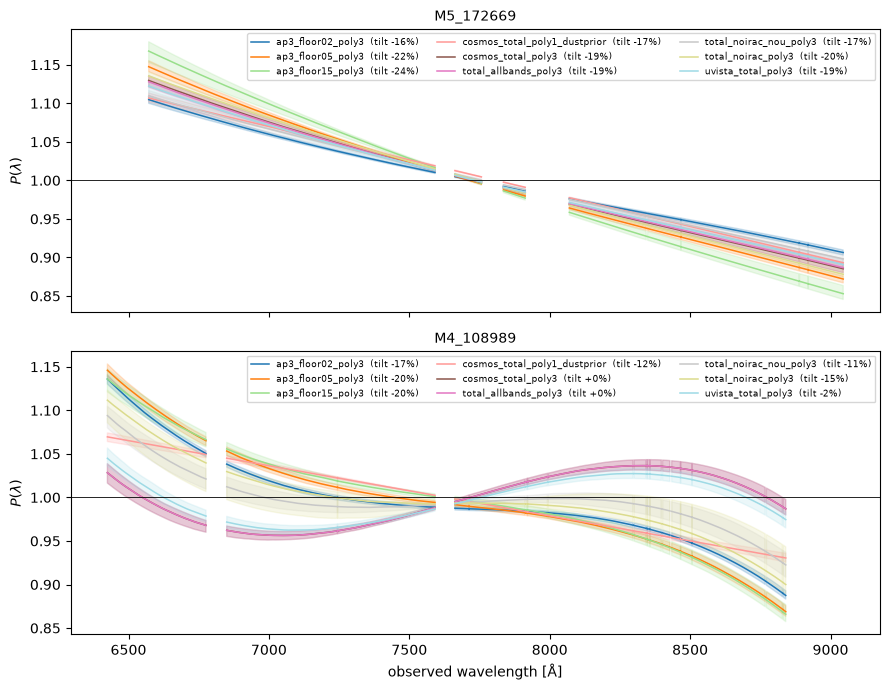

In [4]:
def arms_of(target, *keys):
    return [n for n in runs if runs[n]["config"]["target"] == target and all(k in n for k in keys)]
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
for ax, target in zip(axes, TARGETS):
    names = [n for n in runs if runs[n]["config"]["target"] == target and "poly_q50" in vectors[n].files]
    ax.set_prop_cycle(color=plt.cm.tab20(np.linspace(0, 1, max(len(names), 2))))
    for i, name in enumerate(names):
        v = vectors[name]; w, mk = v["wavelength"], v["mask"]
        colour = plt.cm.tab20(i / max(len(names) - 1, 1))
        ax.fill_between(w, np.where(mk, v["poly_q16"], np.nan), np.where(mk, v["poly_q84"], np.nan), color=colour, alpha=0.2)
        tilt = table.loc[name, "poly_tilt_pct"]
        ax.plot(w, np.where(mk, v["poly_q50"], np.nan), color=colour, lw=1.1, label=f"{name.replace(target + '_', '')}  (tilt {tilt:+.0f}%)")
    ax.axhline(1, color="k", lw=0.6); ax.set_ylabel("$P(\\lambda)$"); ax.set_title(target, fontsize=10); ax.legend(fontsize=6.5, ncol=3)
axes[-1].set_xlabel(r"observed wavelength [$\mathrm{\AA}$]")
fig.tight_layout(); fig.savefig(RESULTS / "polynomial-vectors.png", dpi=140); fig.savefig(WIKI / "calibration-polynomial-tilt-origin-vectors.png", dpi=140)

## Photometric residuals of the median model

- Data / model per band; error bars are the fitted uncertainty (error floor included).

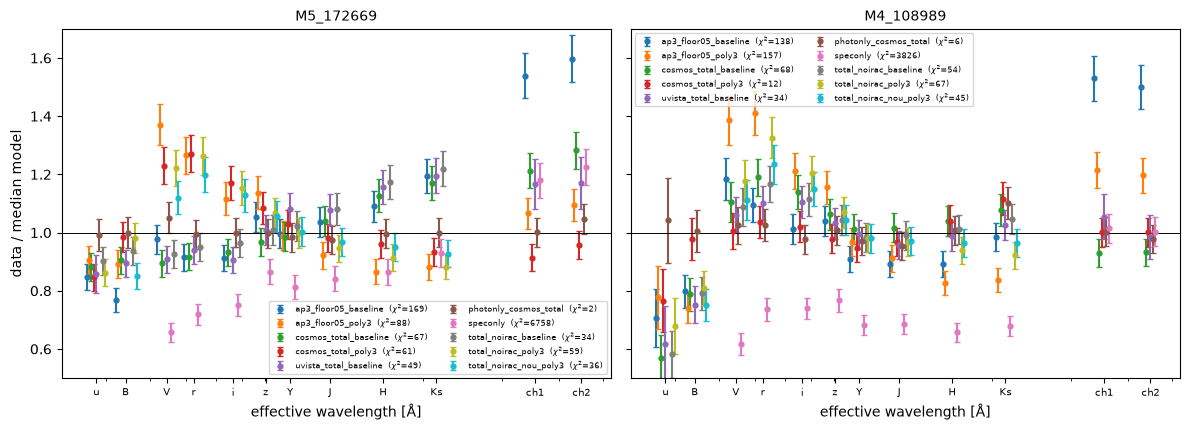

In [5]:
show = ["ap3_floor05_baseline", "ap3_floor05_poly3", "cosmos_total_baseline", "cosmos_total_poly3", "uvista_total_baseline", "photonly_cosmos_total", "speconly",
        "total_noirac_baseline", "total_noirac_poly3", "total_noirac_nou_poly3"]
leff_all = dict(zip(BANDS, [float(f.wave_effective) for f in observate.load_filters(X.FILTER_NAMES)]))
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), sharey=True)
for ax, target in zip(axes, TARGETS):
    for i, key in enumerate(show):
        name = f"{target}_{key}"
        if name not in runs: continue
        v = vectors[name]; ratio = v["phot_flux"] / v["phot_q50"]; err = v["phot_unc"] / v["phot_q50"]
        leff = np.array([leff_all[b] for b in runs[name]["meta"].get("bands", BANDS)])
        ax.errorbar(leff * (1 + 0.012 * (i - 4)), ratio, yerr=err, fmt="o", ms=3.5, capsize=2, color=f"C{i}", label=f"{key}  ($\\chi^2$={runs[name]['posterior']['phot_chi2_q50']:.0f})")
    ax.axhline(1, color="k", lw=0.7); ax.set_xscale("log"); ax.set_title(target, fontsize=10); ax.set_xlabel(r"effective wavelength [$\mathrm{\AA}$]")
    ax.set_xticks(list(leff_all.values())); ax.set_xticklabels(BANDS, fontsize=7); ax.legend(fontsize=6, ncol=2)
    ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
axes[0].set_ylabel("data / median model"); axes[0].set_ylim(0.5, 1.7)
fig.tight_layout(); fig.savefig(RESULTS / "photometry-residuals.png", dpi=140); fig.savefig(WIKI / "calibration-polynomial-tilt-origin-photometry.png", dpi=140)

## Posteriors per arm

- Bars span q16–q84, the point is q50; `tau_dust` is the amplitude of whichever attenuation law the arm used.

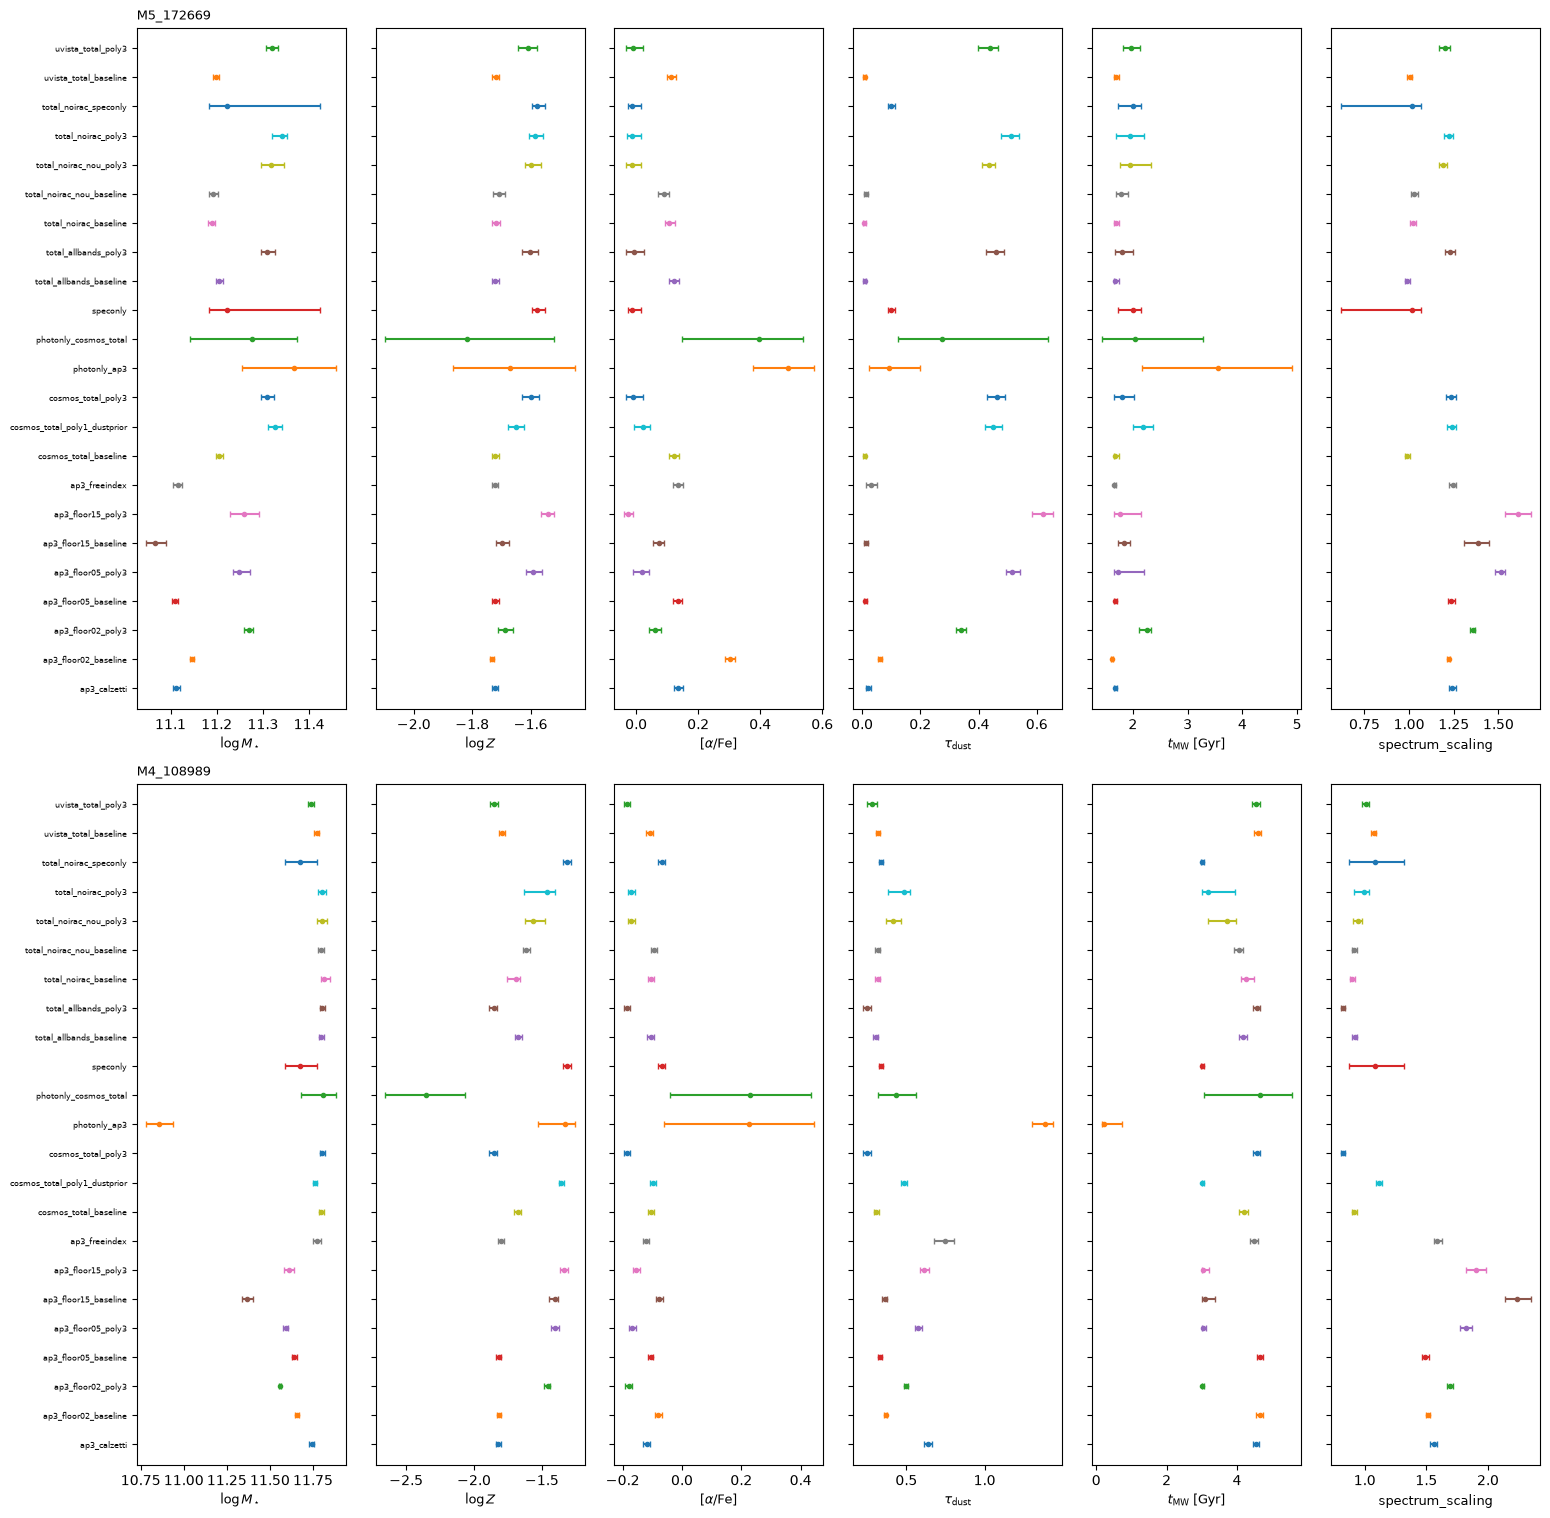

In [6]:
keys = PARAMS + ["spectrum_scaling"]
n_arms = max(sum(runs[n]["config"]["target"] == t for n in runs) for t in TARGETS)
fig, axes = plt.subplots(len(TARGETS), len(keys), figsize=(2.6 * len(keys), (0.28 * n_arms + 1.2) * len(TARGETS)), squeeze=False)
for r, target in enumerate(TARGETS):
    names = [n for n in runs if runs[n]["config"]["target"] == target]
    for c, k in enumerate(keys):
        ax = axes[r, c]
        for i, name in enumerate(names):
            p = runs[name]["posterior"]; q = p.get(amplitude_key(p) if k == "tau_dust" else k)
            if q is None: continue
            ax.errorbar(q["q50"], i, xerr=[[q["q50"] - q["q16"]], [q["q84"] - q["q50"]]], fmt="o", ms=3, color=f"C{i % 10}", capsize=2)
        ax.set_ylim(-0.7, len(names) - 0.3); ax.set_xlabel(LABELS[k], fontsize=9)
        ax.set_yticks(range(len(names))); ax.set_yticklabels([n.replace(target + "_", "") for n in names] if c == 0 else [], fontsize=6)
        if c == 0: ax.set_title(target, fontsize=9, loc="left")
fig.tight_layout(); fig.savefig(RESULTS / "posteriors.png", dpi=140); fig.savefig(WIKI / "calibration-polynomial-tilt-origin-posteriors.png", dpi=140)

## Corner plots and SFH histories

- Equal-weight resample of each stored fit; $t_{\rm MW}$ derived from `logsfr_ratios`.
- Per target: production photometry, corrected photometry, corrected photometry with the polynomial.

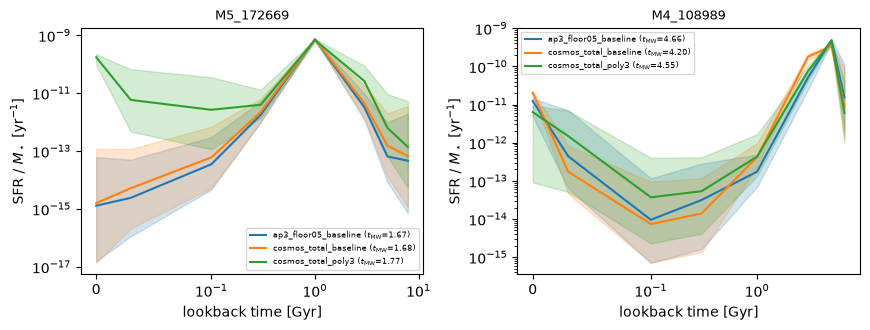

In [7]:
def equal_weight(name, count=3000, seed=1):
    res = load_result_h5(RESULTS / name / "ceridwen_result.h5")
    w = softmax(np.asarray(res.log_weights))
    idx = np.random.default_rng(seed).choice(w.size, size=count, replace=True, p=w)
    return {k: np.asarray(v)[idx] for k, v in res.samples.items()}
def lookback_grid(name):
    return np.array([0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 5.0, float(age_gyr(runs[name]["meta"]["zred"]))])
def derived(samples, lookback):
    hist = np.asarray([np.asarray(logsfr_ratios_to_sfh(r, sfh_times_yr=lookback * 1e9)) for r in samples["logsfr_ratios"]])
    dur = np.diff(lookback) * 1e9; masses = 0.5 * (hist[:, :-1] + hist[:, 1:]) * dur; ages = 0.5 * (lookback[:-1] + lookback[1:])
    return hist, (masses * ages).sum(1) / masses.sum(1)
groups = {t: [n for n in (f"{t}_ap3_floor05_baseline", f"{t}_cosmos_total_baseline", f"{t}_cosmos_total_poly3") if n in runs] for t in TARGETS}
groups = {t: ns for t, ns in groups.items() if ns}
for target, names in groups.items():
    fig = None
    for i, name in enumerate(names):
        s = equal_weight(name); hist, age = derived(s, lookback_grid(name)); amp = amplitude_key(runs[name]["posterior"])
        data = np.column_stack([s["logmass"].ravel(), s["Z"].ravel(), s["afe"].ravel(), s[amp].ravel(), age])
        fig = corner.corner(data, labels=[LABELS[k] for k in PARAMS], color=f"C{i}", fig=fig, plot_datapoints=False, smooth=1.0, hist_kwargs=dict(density=True))
    fig.legend([plt.Line2D([], [], color=f"C{i}") for i in range(len(names))], [n.replace(target + "_", "") for n in names], loc="upper right", fontsize=9)
    fig.suptitle(target); fig.savefig(RESULTS / f"corner-{target}.png", dpi=110); plt.close(fig)
if groups:
    fig, axes = plt.subplots(1, len(groups), figsize=(4.4 * len(groups), 3.4), squeeze=False)
    for ax, (target, names) in zip(axes[0], groups.items()):
        for i, name in enumerate(names):
            s = equal_weight(name, count=600); lb = lookback_grid(name); hist, age = derived(s, lb)
            q16, q50, q84 = np.percentile(hist, [16, 50, 84], axis=0)
            ax.fill_between(lb, q16, q84, color=f"C{i}", alpha=0.2); ax.plot(lb, q50, color=f"C{i}", label=f"{name.replace(target + '_', '')} ($t_{{\\rm MW}}$={np.median(age):.2f})")
        ax.set_xscale("symlog", linthresh=0.1); ax.set_yscale("log"); ax.set_xlabel("lookback time [Gyr]"); ax.set_ylabel(r"SFR / $M_\star$ [yr$^{-1}$]"); ax.set_title(target, fontsize=9); ax.legend(fontsize=6)
    fig.tight_layout(); fig.savefig(RESULTS / "sfh-histories.png", dpi=130)